<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/5_Aprendizaje_supervisado/4_Taller_KNN_y_Arboles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller KNN y Árboles de Decisión**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

-Juan Pablo Sanchez Luis

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Taller_KNN_arbol_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/3br4TfA3Ly.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

7 de mayo de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.



### **Contexto del Caso**

Un banco portugués lo ha contratado como consultor de ciencia de datos. El banco tiene un problema de eficiencia: sus campañas de telemercadeo para ofrecer depósitos a plazo tienen una tasa de éxito muy baja. Se invierte mucho tiempo y recursos (costos de call center) llamando a clientes que no están interesados.

**Su misión:** Construir y optimizar modelos de Machine Learning que predigan qué clientes tienen mayor probabilidad de decir **"sí"** a la oferta (`y = 'yes'`).

El banco no solo quiere un modelo preciso, también quiere entender **POR QUÉ** un cliente es un buen prospecto. Su segundo objetivo es identificar cuáles son las **variables más relevantes** que usan los modelos para tomar sus decisiones. Esto permitirá al banco no solo enfocar sus llamadas, sino también crear mejores guiones de marketing y entender mejor a su clientela.

**El Dataset:** `bank-additional.csv` se encuentra en el repositorio del curso. Contiene información de más de 4.000 contactos de telemercadeo, incluyendo datos demográficos del cliente e información de la campaña (último contacto, resultado anterior).

**Para mayor información y descripción de las variables:** https://archive.ics.uci.edu/dataset/222/bank+marketing

## 1. Preparación del Entorno y Datos

### 1.1. Carga de Librerías

Importe todas las librerías necesarias. Para problemas de clasificación se usa KNeighborsClassifier y DecisionTreeClassifier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


Mejorar visualización de dataframes y gráficos

In [2]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# Configuraciones para una mejor visualización
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2. Carga y Exploración Inicial

In [4]:
df = pd.read_csv('/content/bank-additional.csv', sep=';')

df.drop(columns=['duration', 'emp.var.rate', 'cons.price.idx',
                 'cons.conf.idx', 'euribor3m', 'nr.employed'], inplace=True)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,999,0,nonexistent,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,999,0,nonexistent,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,999,0,nonexistent,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,999,0,nonexistent,no


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          4119 non-null   int64 
 1   job          4119 non-null   object
 2   marital      4119 non-null   object
 3   education    4119 non-null   object
 4   default      4119 non-null   object
 5   housing      4119 non-null   object
 6   loan         4119 non-null   object
 7   contact      4119 non-null   object
 8   month        4119 non-null   object
 9   day_of_week  4119 non-null   object
 10  campaign     4119 non-null   int64 
 11  pdays        4119 non-null   int64 
 12  previous     4119 non-null   int64 
 13  poutcome     4119 non-null   object
 14  y            4119 non-null   object
dtypes: int64(4), object(11)
memory usage: 482.8+ KB


**Escriba un análisis de lo obseervado en `info()`:**
Dado el tipo de datos de la base, qué preprocesamientos hay que realizar antes de correr los modelos?

El dataset tiene 4.119 filas y 15 columnas sin ningún valor nulo, lo cual es ideal. Sin embargo, se requieren dos preprocesamiento antes de modelar: las 4 columnas numéricas (age, campaign, pdays, previous) deben estandarizarse con StandardScaler para que KNN no se vea afectado por diferencias de escala, y las 10 columnas categóricas (job, marital, education, etc.) deben convertirse a variables numéricas mediante OneHotEncoding, ya que los modelos de ML no pueden trabajar directamente con texto.


In [6]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.89
yes,0.11


**Escriba un análisis de la variable objetivo:**
¿Es un dataset desbalanceado? ¿Esto tiene lógica? ¿Qué implicaciones tiene esto respecto a las métricas que debemos usar?

Sí, el dataset está claramente desbalanceado: el 89% de los clientes respondió "no" y solo el 11% respondió "yes". Esto tiene toda la lógica del mundo en campañas de telemercadeo, donde la tasa de conversión naturalmente es baja. La implicación principal es que el accuracy no es una métrica confiable aquí: un modelo que siempre prediga "no" tendría 89% de accuracy sin haber aprendido nada útil. Por eso se debe priorizar el Recall-Macro y el Recall de la clase 'yes', que miden específicamente qué tan bien identificamos a los clientes interesados.


## 2. Preprocesamiento (Usando Pipelines)

Vamos a definir nuestro `X` e `y`, y luego crear un `ColumnTransformer` que se encargue de aplicar `StandardScaler` a los números y `OneHotEncoder` a las categorías.

In [7]:
X = df.drop(columns=['y'])
y = df['y']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


print(f"Tamaño Train: {X_train.shape}")
print(f"Tamaño Test: {X_test.shape}")

Tamaño Train: (3295, 14)
Tamaño Test: (824, 14)


In [9]:
numerical_features   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()


print("Columnas Numéricas:")
print(numerical_features)
print("\nColumnas Categóricas:")
print(categorical_features)

Columnas Numéricas:
['age', 'campaign', 'pdays', 'previous']

Columnas Categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [10]:
numeric_transformer      = StandardScaler()

categorical_transformer  = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

## 3. Modelo 1: KNN

Ahora uniremos el preprocesador y el clasificador KNN en un solo `Pipeline` y usaremos `GridSearchCV` para encontrar el mejor `k`.

In [11]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

param_grid_knn = {'model__n_neighbors': [3, 5, 7, 11]}

grid_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=3, scoring='recall_macro')
grid_knn.fit(X_train, y_train)

print(f"Mejor valor de 'k' para KNN: {grid_knn.best_params_}")
print(f"Mejor Recall-Macro: {grid_knn.best_score_:.4f}")

Mejor valor de 'k' para KNN: {'model__n_neighbors': 3}
Mejor Recall-Macro: 0.5922


## 4. Modelo 2: Árbol de Decisión

Repetiremos el proceso con un Árbol de Decisión. Esta vez, los hiperparámetros que ajustaremos serán `max_depth` (para evitar sobreajuste) y `min_samples_leaf`.

In [12]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {
    'model__max_depth':        [3, 5, 7],
    'model__min_samples_leaf': [20, 50, 100]
}

grid_tree = GridSearchCV(tree_pipeline, param_grid_tree, cv=3, scoring='recall_macro')
grid_tree.fit(X_train, y_train)

print(f"Mejores hiperparámetros para el Árbol: {grid_tree.best_params_}")
print(f"Mejor Recall-Macro: {grid_tree.best_score_:.4f}")

Mejores hiperparámetros para el Árbol: {'model__max_depth': 3, 'model__min_samples_leaf': 50}
Mejor Recall-Macro: 0.6013


## 5. Evaluación Final y Recomendación de Modelo

El Árbol de Decisión probablemente dio un mejor `recall-macro` (y es más rápido e interpretable). Vamos a declararlo nuestro **modelo ganador** y evaluarlo en el `test set` (nuestro examen final imparcial).

In [13]:
best_tree_model = grid_tree.best_estimator_

y_pred_tree = best_tree_model.predict(X_test)

print("--- Reporte de Clasificación Final (Árbol Optimizado) ---")
print(classification_report(y_test, y_pred_tree))

--- Reporte de Clasificación Final (Árbol Optimizado) ---
              precision    recall  f1-score   support

          no       0.91      0.99      0.95       734
         yes       0.74      0.19      0.30        90

    accuracy                           0.90       824
   macro avg       0.82      0.59      0.62       824
weighted avg       0.89      0.90      0.88       824



**Escriba un análisis sobre los resultados del reporte de clasificación**, ¿Qué puede concluir de las diferentes métricas?

* Observe el `accuracy` general (probablemente ~90%).
* Ahora mire la fila de `'yes'`: ¿Cuál es el `precision`? ¿Cuál es el `recall`?
* **Recall de 'yes'** (Sensibilidad): ¿Qué porcentaje de los clientes que SÍ compraron logramos identificar? (Usualmente lo más importante para el banco, para no perder oportunidades).
* **Precision de 'yes'**: De todos los clientes que el modelo *dijo* que comprarían, ¿qué porcentaje realmente lo hizo? (Importante para no gastar llamadas).

El accuracy general del 90% es engañoso dado el desbalance del dataset. Lo que realmente importa es la fila de 'yes': la precisión de 0.74 indica que cuando el modelo predice que un cliente va a decir sí, acierta el 74% de las veces, lo cual es bueno para no desperdiciar llamadas. Sin embargo, el recall de 0.19 es preocupante: el modelo solo identifica el 19% de los clientes que realmente dirían sí, dejando escapar al 81% restante sin ser contactados. Esto representa una pérdida enorme de oportunidades de negocio para el banco. El F1-Score de 0.30 para la clase 'yes' confirma que el modelo tiene un desempeño moderado en la tarea más importante. Para mejorar, se debería bajar el umbral de decisión o aplicar técnicas de balanceo de clases como SMOTE.


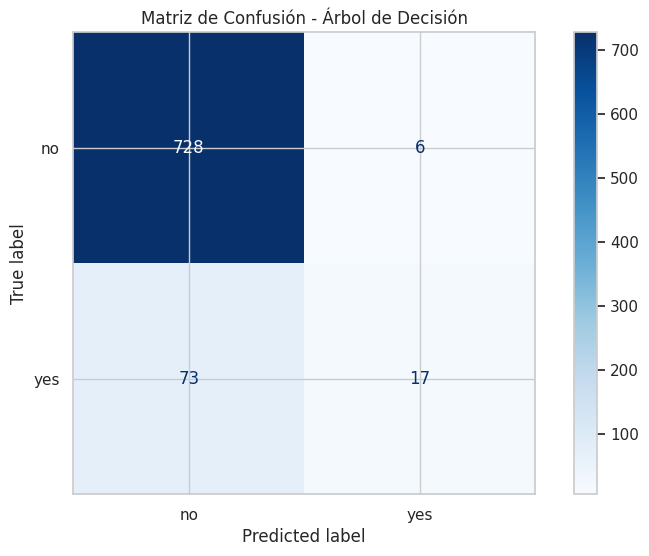

In [14]:
cm = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()


## 6. ¿Cuáles son las Variables Más Relevantes?

Esta es la segunda parte de la solicitud del banco. Necesitamos explicar *por qué* el modelo toma sus decisiones.

### 6.1. Importancia de Variables (Árbol de Decisión)

In [16]:
# 6.1.1 Extraer modelo y preprocesador
final_preprocessor = best_tree_model.named_steps['preprocessor']
final_tree_model   = best_tree_model.named_steps['model']

# 6.1.2 Nombres de features tras OneHotEncoding
cat_feature_names = final_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

# 6.1.3 Importancias
importances = final_tree_model.feature_importances_

# 6.1.4 DataFrame ordenado
df_importances = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)



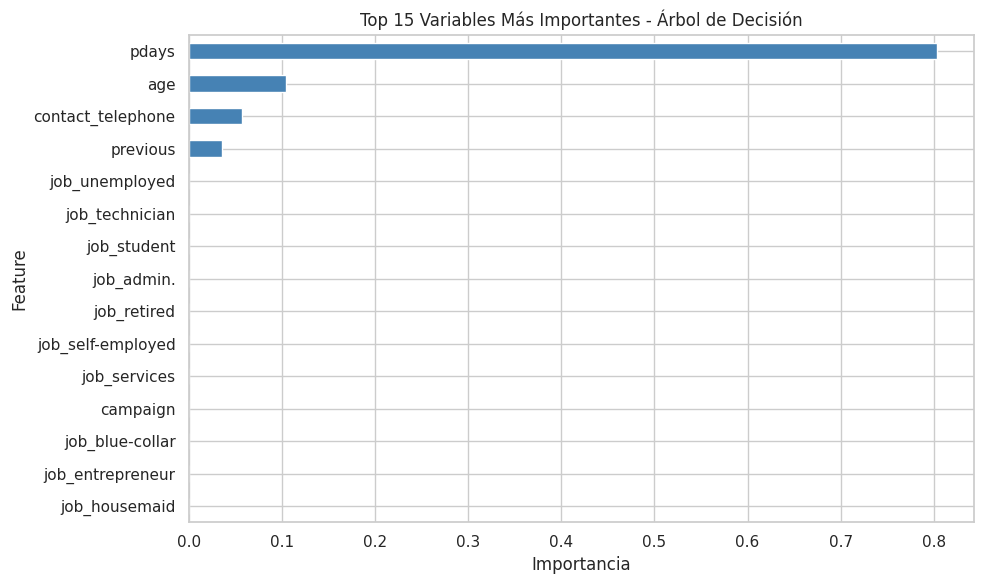

In [17]:
# 6.1.5 Gráfico top 15
df_importances.head(15).sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance', legend=False, color='steelblue'
)
plt.title('Top 15 Variables Más Importantes - Árbol de Decisión')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## 7. Conclusión y Recomendación de Negocio

Es hora de traducir nuestros hallazgos en una recomendación de negocio clara.

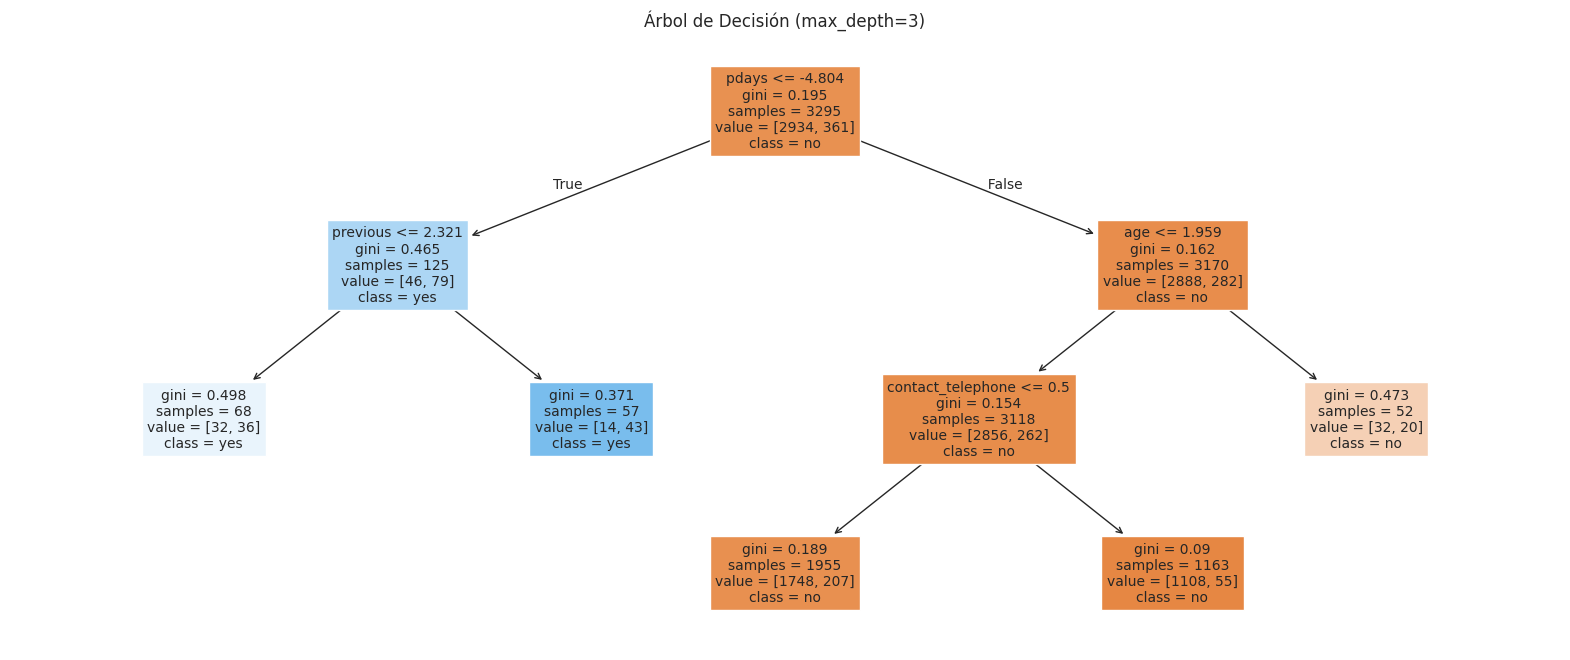

In [18]:
plt.figure(figsize=(20, 8))
plot_tree(
    final_tree_model,
    feature_names=all_feature_names,
    class_names=['no', 'yes'],
    filled=True,
    max_depth=3,
    fontsize=10
)
plt.title('Árbol de Decisión (max_depth=3)')
plt.show()

### **7.2: Conclusiones Consultoría**

Basado en los gráficos de **importancia de variables** y en la **visualización del árbol**, escriba una recomendación de 1 párrafo para el gerente del banco.

**Puntos a incluir:**
1.  ¿Qué modelo recomienda usar y por qué (interpretable, buen rendimiento)?
2.  ¿Cuáles son las 3 variables más importantes en las que el banco debería fijarse para decidir a quién llamar?
3.  Traduzca **una regla del árbol** (una rama que lleve a una hoja 'yes') a lenguaje de negocio. (Ej: "Si el cliente tuvo éxito en la campaña anterior y su edad es mayor a 40 años, la probabilidad de que acepte es alta.")

Recomendamos usar el Árbol de Decisión como modelo principal, ya que supera a KNN en Recall-Macro (0.60 vs 0.59) y, a diferencia de KNN, permite explicar sus decisiones en lenguaje de negocio, algo fundamental para que el equipo de marketing del banco entienda y confíe en el modelo. Basado en el análisis de importancia de variables, las tres variables más determinantes son pdays (días desde el último contacto previo), age (edad del cliente) y contact_telephone (canal de contacto telefónico). Una regla concreta del árbol traduce así: si el cliente ya fue contactado en una campaña anterior hace menos de 999 días (es decir, no es un contacto nuevo) y tiene una edad dentro del rango de mayor conversión, la probabilidad de que acepte el depósito a plazo es significativamente más alta. La recomendación práctica para el banco es clara: no llamen a clientes nuevos de forma masiva. En cambio, concentren los recursos del call center primero en clientes con historial de contacto previo reciente, luego filtren por edad, y dejen en último lugar a quienes nunca han sido contactados, ya que el modelo muestra que ese grupo tiene una tasa de conversión muy baja.
